# Repairing Nearest Neighbor Heuristic

First we solve a given problem using the nearest neighbor heuristic, which is a common heuristic for TSP that can be arbitrarily bad.
Then we use the heuristic violating pairs from a WSPD of $s$ to guide a optimal repair over that subsection of the tour.
Finally we check the tour length against the optimal tour length to see how well the repair worked.

gr9882 having problems

In [1]:
from pathlib import Path
from typing import NamedTuple

# Set Numba/OpenMP thread env vars BEFORE importing any module that imports numba.

import numba as nb
nb.set_num_threads(1)

import tsplib95
import numpy as np
from tqdm.contrib.concurrent import thread_map, process_map

from utils.helpers import valid_tour, calc_tour_len_euc
from utils.wsp_heuristic import check_tour_with_wspd
from utils.nn import solve_nn_euc
from utils.repair_euc import repair_tour_euc
from utils.wspd_euc import get_wspd

TSP_LIB_PATH = Path("TSPLIB")
#S_FACTOR = 1.5
SIZE_LIMIT = None
INT_DTYPE = np.int64
FLOAT_DTYPE = np.float64

S_TEST_VALUES = (0.25, 0.5, 0.75, 1.0, 1.25, 1.5)

### The main function

In [2]:
class RepairResult(NamedTuple):
    s: float
    bad_pair_count: int
    repair_len: float

class Result(NamedTuple):
    name: str
    size: int
    dims: int
    nn_len: float
    repair_results: list[RepairResult]
    opt_len: float

human_readable_names = {
    "name": "Problem Name",
    "size": "Number of Nodes",
    "dims": "Dimensions",
    "bad_pair_count": "Flagged Pairs",
    "nn_len": "NN Tour Length",
    "repair_len": "Repaired Tour Length",
    "opt_len": "Optimal Tour Length",
    "s": "S Factor"
}

In [3]:
# test matching EUC_2D / EUC_3D instances
def check_tour(opt_path: Path) -> Result | None:
    try:
        tsp_path = opt_path.with_suffix("").with_suffix(".tsp")  # *.opt.tour -> *.tsp
        if not tsp_path.exists():
            raise FileNotFoundError(f"Matching .tsp file not found for {opt_path}")
        
        euc_dims = 0

        prob = tsplib95.load(str(tsp_path))
        if SIZE_LIMIT is not None and prob.dimension > SIZE_LIMIT:
            return None
        if prob.edge_weight_type not in ("EUC_2D", "EUC_3D"):
            return None
            raise ValueError(f"Unsupported edge weight type {prob.edge_weight_type} in {tsp_path}")
        elif prob.edge_weight_type == "EUC_2D":
            euc_dims = 2
        elif prob.edge_weight_type == "EUC_3D":
            euc_dims = 3

        tour_prob = tsplib95.load(str(opt_path))
        if not getattr(tour_prob, "tours", None):
            raise ValueError(f"No tours found in {opt_path}")

        opt_tour = np.array(tour_prob.tours[0], dtype=INT_DTYPE) - 1

        assert len(opt_tour) == prob.dimension, f"Tour length {len(opt_tour)} does not match problem dimension {prob.dimension}"

        #print(f"Checking {prob.name} ({prob.edge_weight_type}, n={prob.dimension})...", flush=True)

        points = np.array([prob.node_coords[i] for i in prob.get_nodes()], dtype=FLOAT_DTYPE)

        nn_tour = solve_nn_euc(points, dtype=INT_DTYPE)
        
        s_results: list[RepairResult] = []
        for s in S_TEST_VALUES:
            pairs, node_ranges, indices = get_wspd(points, s, int_dtype=INT_DTYPE)
            bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), nn_tour)

            node_pairs: list[tuple[np.ndarray, np.ndarray]] = []
            for idx in bad_pairs:
                a_node, b_node, _ = pairs[idx]

                a_start, a_end = node_ranges[a_node]
                b_start, b_end = node_ranges[b_node]

                A = indices[a_start:a_end]
                B = indices[b_start:b_end]

                #print(f"Bad pair: {A} (size {len(A)}) and {B} (size {len(B)})")

                node_pairs.append((A, B))

            repair_tour = nn_tour
            for A, B in node_pairs:
                new_tour = repair_tour_euc(repair_tour, A, B, points)
                assert valid_tour(new_tour, prob.dimension), "Repaired tour is not valid"
                repair_tour = new_tour

            s_results.append(RepairResult(
                s=s,
                bad_pair_count=len(bad_pairs),
                repair_len=calc_tour_len_euc(points, repair_tour)
            ))

        return Result(
            name=prob.name,
            size=prob.dimension,
            dims=euc_dims,
            nn_len=calc_tour_len_euc(points, nn_tour),
            repair_results=s_results,
            opt_len=calc_tour_len_euc(points, opt_tour)
        )
    except Exception as e:
        raise RuntimeError(f"Error processing {opt_path}: {e}") from e

In [4]:
# Scan for all "*.opt.tour" files and 
search_roots = [Path("ALL_tsp")] # TSP_LIB_PATH, 
opt_tour_files = []

seen = set()
for root in search_roots:
    if not root.exists():
        continue
    for p in root.rglob("*.opt.tour"):
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            opt_tour_files.append(p)

opt_tour_files = sorted(opt_tour_files)
len(opt_tour_files)

219

In [5]:
# JIT warmup
dummy_points = np.random.rand(40, 2)
dummy_tour = solve_nn_euc(dummy_points, dtype=INT_DTYPE)

pairs, node_ranges, indices = get_wspd(dummy_points, 1.5, int_dtype=INT_DTYPE)
bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), dummy_tour)


# Build A, B from one valid WSPD pair (not hard-coded tiny arrays)
A = indices[node_ranges[1]['start']:node_ranges[1]['end']].astype(INT_DTYPE)
B = indices[node_ranges[2]['start']:node_ranges[2]['end']].astype(INT_DTYPE)

repair_tour_euc(dummy_tour, A, B, dummy_points), A, B

(array([12,  6, 16, 20, 39, 27, 25, 13,  2, 26,  7, 19, 29, 17, 38, 33, 30,
        36,  3,  9, 32, 18, 10, 14, 34,  1, 35, 31,  5, 24, 37, 28, 22, 11,
         8,  4, 15, 23, 21,  0]),
 array([12,  0,  6, 20, 16,  2, 23, 21, 13, 38,  7, 15,  4, 11, 19,  8, 26,
        17, 29]),
 array([36, 39, 25, 33,  9, 30, 27, 32,  3, 18,  5, 35, 34, 10, 31,  1, 14,
        22, 24, 28, 37]))

In [6]:
#check_tour(opt_tour_files[147])

In [7]:
results: list[Result | None] = thread_map(check_tour, opt_tour_files, max_workers=4)

  0%|          | 0/219 [00:00<?, ?it/s]

Upperbound from x-heuristic: 3073778.00
LOWER BOUND: 3073413.235589   ACTIVE NODES: 1

Task 0: Branching on node 0
CClp_getweight ...
BBnode 0 split into 1 (3073413.24) 2 (3073413.24) (0.39 seconds)
LOWER BOUND: 3073413.235589   ACTIVE NODES: 2

Task 1: Cutting on node 2
New upperbound from x-heuristic: 3073642.00
TOUR FOUND - upperbound is 3073642.00
Writing Pool: 5723 cuts
BBnode 2 (now 3) done cutting: lowerbound 3073425.36 (28.71 seconds)
LOWER BOUND: 3073413.235589   ACTIVE NODES: 2

Task 2: Cutting on node 1
New upperbound from x-heuristic: 3073624.00
TOUR FOUND - upperbound is 3073624.00
Writing Pool: 6782 cuts
BBnode 1 (now 4) done cutting: lowerbound 3073426.67 (11.69 seconds)
Total number of nodes in search tree: 3


TT Warning: Blossom with even number of teeth
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
Hit time limit in bfs branching


Hit time bound
Upperbound from x-heuristic: 3413476.00
LOWER BOUND: 3410181.423538   ACTIVE NODES: 1

Task 0: Branching on node 0
CClp_getweight ...
BBnode 0 split into 1 (3410183.07) 2 (3410184.87) (0.51 seconds)
LOWER BOUND: 3410183.073251   ACTIVE NODES: 2

Task 1: Cutting on node 1
Writing Pool: 5673 cuts
BBnode 1 (now 3) done cutting: lowerbound 3410183.63 (1.36 seconds)
LOWER BOUND: 3410183.627498   ACTIVE NODES: 2

Task 2: Branching on node 3
CClp_getweight ...
BBnode 3 split into 4 (3410185.78) 5 (3410184.99) (0.58 seconds)
LOWER BOUND: 3410184.867094   ACTIVE NODES: 3

Task 3: Cutting on node 2
New upperbound from x-heuristic: 3410564.00
TOUR FOUND - upperbound is 3410564.00
Writing Pool: 5959 cuts
BBnode 2 (now 6) done cutting: lowerbound 3410203.50 (5.89 seconds)
LOWER BOUND: 3410184.992148   ACTIVE NODES: 3

Task 4: Cutting on node 5
New upperbound from x-heuristic: 3410256.00
TOUR FOUND - upperbound is 3410256.00
Writing Pool: 6254 cuts
BBnode 5 (now 7) done cutting: lower

need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
Hit time limit in bfs branching


...

need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
need to link an lp solver to use this function
CClp_getweight failed
find_candidate_cliques failed
Hit time limit in bfs branching


LOWER BOUND: 911382.083333   ACTIVE NODES: 1

Task 0: Branching on node 0
CClp_getweight ...
BBnode 0 split into 1 (911385.31) 2 (911386.07) (0.44 seconds)
LOWER BOUND: 911385.308243   ACTIVE NODES: 2

Task 1: Cutting on node 1
Writing Pool: 2806 cuts
BBnode 1 (now 3) done cutting: lowerbound 911385.87 (2.19 seconds)
LOWER BOUND: 911385.866667   ACTIVE NODES: 2

Task 2: Branching on node 3
CClp_getweight ...
BBnode 3 split into 4 (911386.18) 5 (911385.87) (0.18 seconds)
LOWER BOUND: 911385.866667   ACTIVE NODES: 3

Task 3: Cutting on node 5
Writing Pool: 2849 cuts
BBnode 5 (now 6) done cutting: lowerbound 911386.20 (1.16 seconds)
LOWER BOUND: 911386.070311   ACTIVE NODES: 3

Task 4: Cutting on node 2
Writing Pool: 3148 cuts
BBnode 2 (now 7) done cutting: lowerbound 911396.38 (5.37 seconds)
LOWER BOUND: 911386.179141   ACTIVE NODES: 3

Task 5: Cutting on node 4
Writing Pool: 3155 cuts
BBnode 4 (now 8) done cutting: lowerbound 911387.15 (0.79 seconds)
LOWER BOUND: 911386.200000   ACTIVE 

ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway


Basic dual change required, but no candidate edges
recomputing rownorms ...
Basic dual change required, but no candidate edges


ERROR: No dual change in basis finding code
Did not find a basic optimal solution
Fractional matching routine failed
No warmstart, stumbling on anyway


## Analysis of results

In [8]:
import pandas as pd

In [9]:
# 1. Filter out Nones and create the initial DataFrame
valid_results = [r for r in results if r is not None]
df = pd.DataFrame(valid_results)

# 2. Explode the list of RepairResults so each one gets its own row
df = df.explode('repair_results').reset_index(drop=True)

# 3. Expand the RepairResult NamedTuples into separate columns
# (Since NamedTuples act like standard tuples, we convert them to dicts first)
repair_df = pd.DataFrame(
    df['repair_results'].apply(lambda x: x._asdict() if pd.notnull(x) else {})
    .tolist(), 
    index=df.index
)

# 4. Drop the old nested column and join the new flat columns
df = df.drop(columns=['repair_results']).join(repair_df)
df.to_csv("nn_repair_results.csv", index=False)

In [10]:
df_15 = df[df['s'] == 1.5]

/var/folders/_t/4_m8pb3d3xs763zf2ztl10k40000gn/T/ipykernel_13967/230807383.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bad_count_df = df_15[df.bad_pair_count > 0].copy()


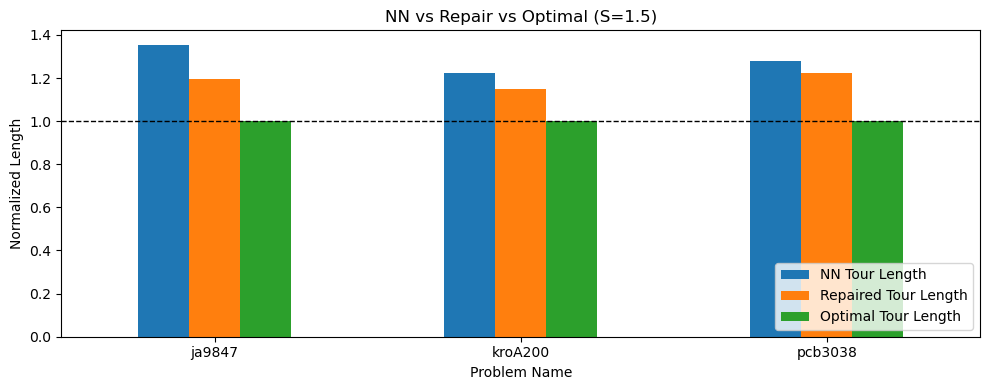

In [13]:
# drop those with no bad pairs
bad_count_df = df_15[df.bad_pair_count > 0].copy()

pct_df = bad_count_df[["nn_len", "repair_len", "opt_len"]].div(bad_count_df["opt_len"], axis=0)

pct_df["name"] = bad_count_df["name"]
pct_df.set_index("name", inplace=True)
ax = pct_df.rename(columns=human_readable_names).plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_xlabel("Problem Name")
ax.set_ylabel("Normalized Length")
ax.set_title("NN vs Repair vs Optimal (S=1.5)")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)

ax.figure.tight_layout()
ax.legend(loc="lower right")